In [101]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [102]:
df = pd.read_csv("../dataset/startup data.csv")

In [103]:
df.head()

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


In [104]:
df.shape

(923, 49)

In [105]:
df.shape

(923, 49)

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    str    
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    str    
 5   id                        923 non-null    str    
 6   city                      923 non-null    str    
 7   Unnamed: 6                430 non-null    str    
 8   name                      923 non-null    str    
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    str    
 11  closed_at                 335 non-null    str    
 12  first_funding_at          923 non-null    str    
 13  last_funding_at           923 non-null    str    
 14  age_first_funding_yea

In [107]:
df.describe(include="all")

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
count,923.000000,923,923.000000,923.000000,923,923,923,430,923,923.000000,...,923,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923
unique,NaN,35,NaN,NaN,382,922,221,252,922,NaN,...,922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,CA,NaN,NaN,94107,c:28482,San Francisco,San Francisco CA 94105,Redwood Systems,NaN,...,c:28482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acquired
freq,NaN,488,NaN,NaN,30,2,128,12,2,NaN,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,597
mean,572.297941,NaN,38.517442,-103.539212,NaN,NaN,NaN,NaN,NaN,0.646804,...,NaN,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317,NaN
std,333.585431,NaN,3.741497,22.394167,NaN,NaN,NaN,NaN,NaN,0.478222,...,NaN,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052,NaN
min,1.000000,NaN,25.752358,-122.756956,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN
25%,283.500000,NaN,37.388869,-122.198732,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000,NaN
50%,577.000000,NaN,37.779281,-118.374037,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000,NaN
75%,866.500000,NaN,40.730646,-77.214731,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000,NaN


In [108]:
df.isnull().sum().sort_values(ascending=False)

closed_at                   588
Unnamed: 6                  493
age_first_milestone_year    152
age_last_milestone_year     152
state_code.1                  1
zip_code                      0
id                            0
Unnamed: 0                    0
state_code                    0
name                          0
city                          0
founded_at                    0
labels                        0
first_funding_at              0
last_funding_at               0
longitude                     0
latitude                      0
age_last_funding_year         0
age_first_funding_year        0
funding_rounds                0
relationships                 0
funding_total_usd             0
milestones                    0
is_CA                         0
is_NY                         0
is_MA                         0
is_TX                         0
is_otherstate                 0
category_code                 0
is_software                   0
is_web                        0
is_mobil

In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
df = df.drop_duplicates()

In [111]:
drop_columns = [
    "Unnamed: 0",
    "labels",
    "state_code",
    "latitude",
    "longitude",
    "zip_code",
    "city",
    "region",
    "country_code",
    "name",
    "permalink",
    "homepage_url",
    "created_at",
    "closed_at",
    "first_funding_at",
    "last_funding_at"
]

df = df.drop(columns=drop_columns, errors="ignore")

In [112]:
df.columns

Index(['id', 'Unnamed: 6', 'founded_at', 'age_first_funding_year',
       'age_last_funding_year', 'age_first_milestone_year',
       'age_last_milestone_year', 'relationships', 'funding_rounds',
       'funding_total_usd', 'milestones', 'state_code.1', 'is_CA', 'is_NY',
       'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software',
       'is_web', 'is_mobile', 'is_enterprise', 'is_advertising',
       'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting',
       'is_othercategory', 'object_id', 'has_VC', 'has_angel', 'has_roundA',
       'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants',
       'is_top500', 'status'],
      dtype='str')

In [113]:
success = ["acquired", "ipo", "operating"]

df["status"] = df["status"].apply(
    lambda x: 1 if str(x).lower() in success else 0
)

In [114]:
df["status"].value_counts()

status
1    597
0    326
Name: count, dtype: int64

In [115]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [116]:
df = df.dropna(axis=1, how="all")

In [117]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\HP\AppData\Local\Temp\ipykernel_13020\1429162425.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


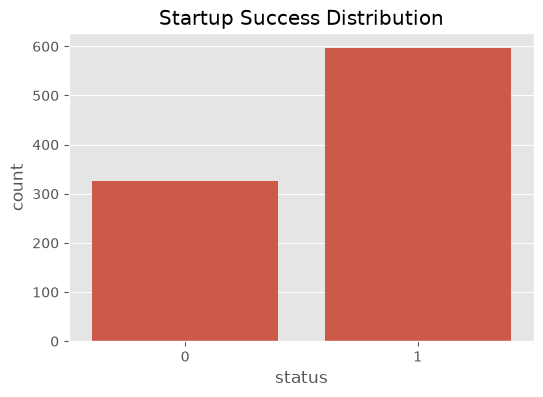

In [118]:
plt.figure(figsize=(6,4))

sns.countplot(x="status", data=df)

plt.title("Startup Success Distribution")

plt.show()

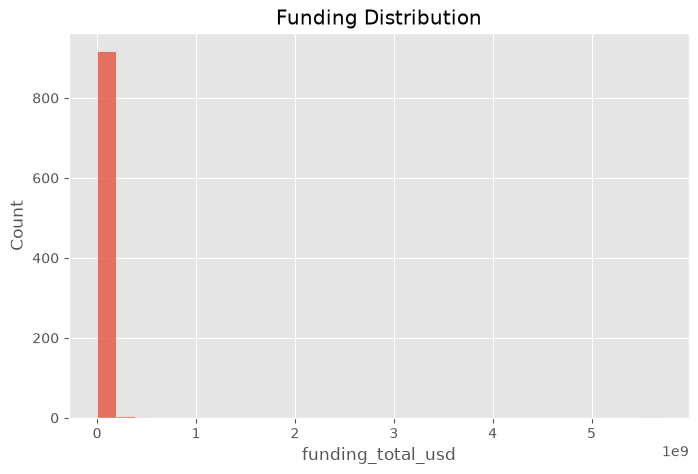

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(df["funding_total_usd"], bins=30)

plt.title("Funding Distribution")

plt.show()

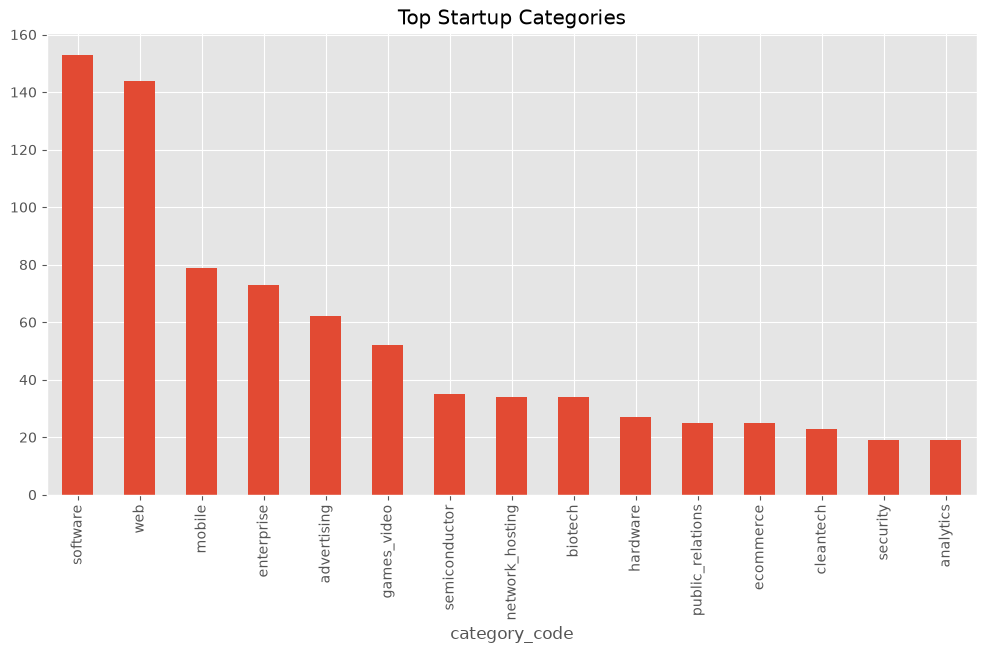

In [120]:
plt.figure(figsize=(12,6))

df["category_code"].value_counts().head(15).plot(kind="bar")

plt.title("Top Startup Categories")

plt.show()

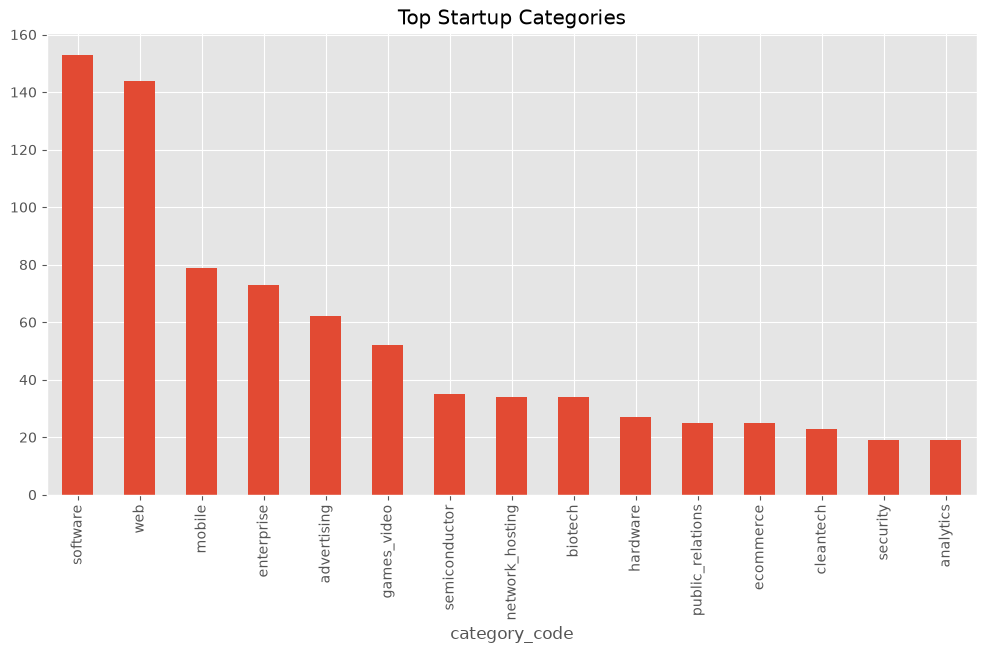

In [121]:
plt.figure(figsize=(12,6))

df["category_code"].value_counts().head(15).plot(kind="bar")

plt.title("Top Startup Categories")

plt.show()

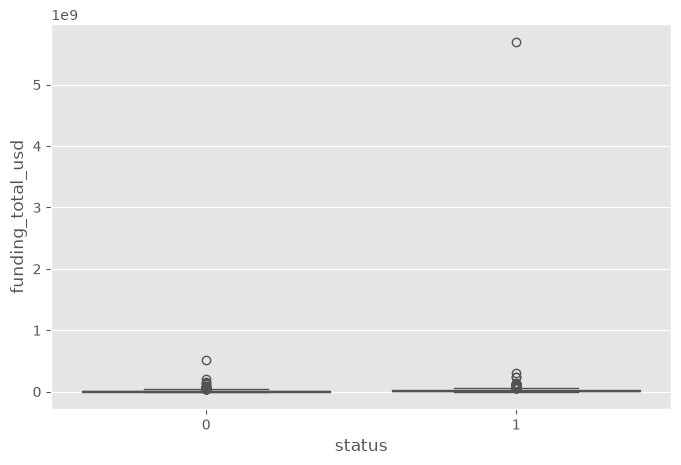

In [122]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="status",
    y="funding_total_usd",
    data=df
)

plt.show()

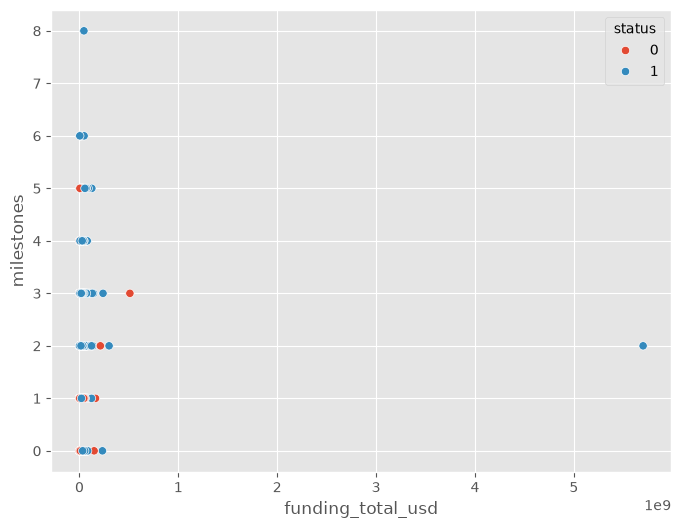

In [123]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="funding_total_usd",
    y="milestones",
    hue="status",
    data=df
)

plt.show()

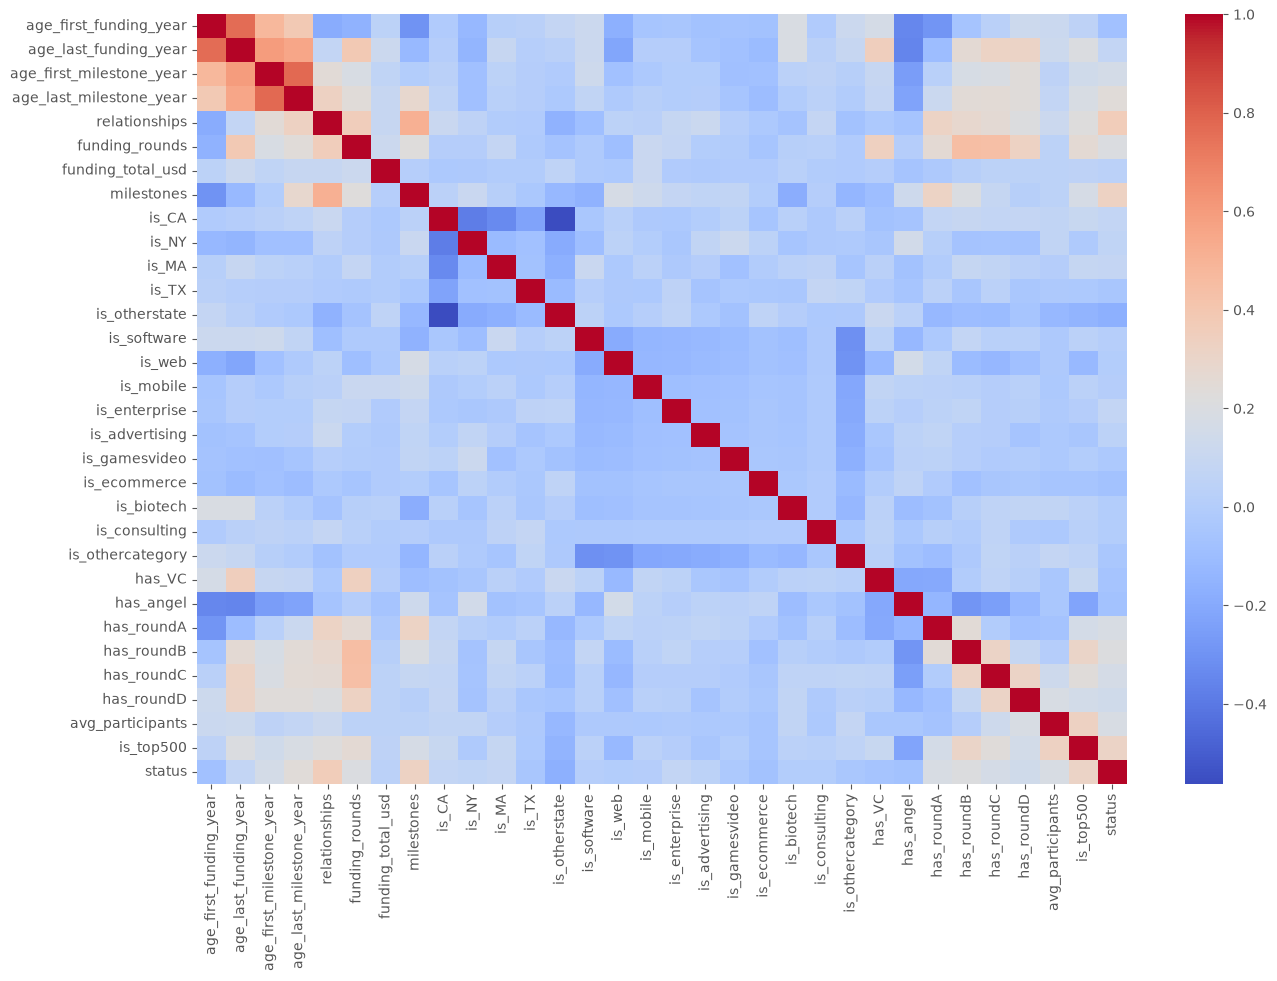

In [124]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [125]:
df.to_csv("../dataset/clean_data.csv", index=False)

In [126]:
import os
print(os.getcwd())

c:\Users\HP\Documents\AI-Startup-Success-Predictor\notebook


In [127]:
df.to_csv("../dataset/clean_data.csv", index=False)

In [128]:
import os

save_path = "../dataset/clean_data.csv"

df.to_csv(save_path, index=False)

print("Saved Successfully!")
print("File Exists:", os.path.exists(save_path))
print("Absolute Path:", os.path.abspath(save_path))

Saved Successfully!
File Exists: True
Absolute Path: c:\Users\HP\Documents\AI-Startup-Success-Predictor\dataset\clean_data.csv
